   trip_id  driver_id  rider_id           city  pickup_lat  pickup_lng  \
0        1       8270     10683  San Francisco   37.170931  -77.586479   
1        2       1860     44743         Boston   38.898127 -108.582977   
2        3       6390     75839  San Francisco   38.814571  -89.942603   
3        4       6191     22189       New York   37.295906  -75.328844   
4        5       6734     61104        Seattle   38.972395 -121.482913   

    drop_lat    drop_lng  distance_km  fare_amount     status payment_method  \
0  37.173652  -77.619934         2.97        10.71  Completed         Wallet   
1  38.937464 -108.558727         8.43        22.41  Completed            UPI   
2  38.821702  -89.896435         5.46        12.91  Completed           Cash   
3  37.301375  -75.317488         6.61        15.70  Completed         Wallet   
4  38.992088 -121.467904        10.50        19.15  Completed         Wallet   

           pickup_time                      drop_time  
0  2023-01-01 00:0

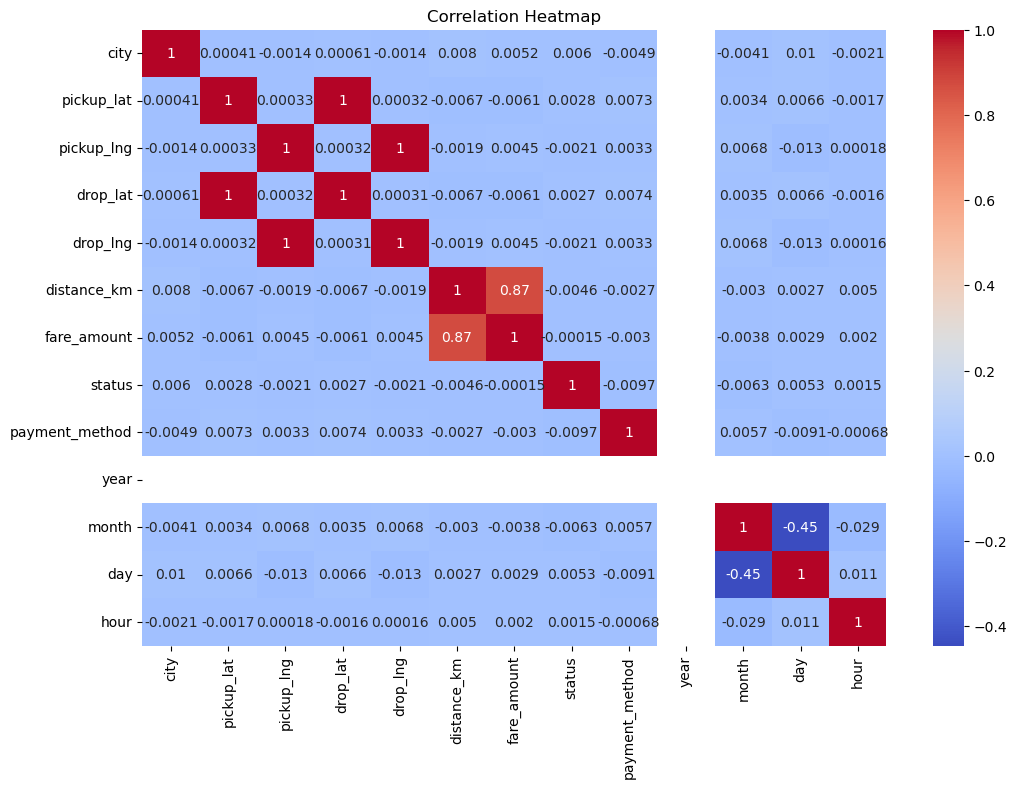

MAE : 2.4879188725230508
MSE : 9.621176921512596
R2 Score : 0.7610103754362105


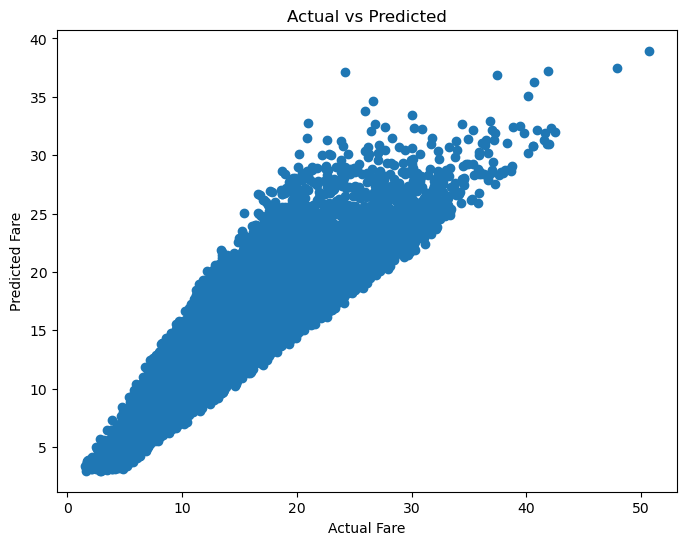

           Feature    Importance
5      distance_km  1.849283e+00
1       pickup_lat  3.430495e-01
4         drop_lng  1.946992e-01
6           status  5.210972e-02
7   payment_method  2.587872e-03
10             day  7.313600e-04
8             year  2.220446e-16
11            hour -9.071565e-04
0             city -1.418756e-02
9            month -2.597701e-02
2       pickup_lng -1.919791e-01
3         drop_lat -3.452380e-01


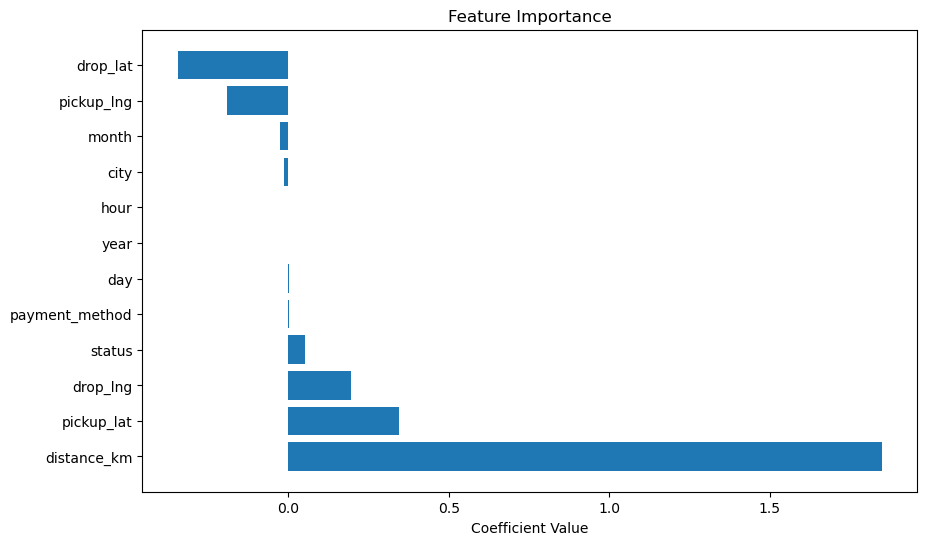

Predicted Fare: 418.73093165178597


In [4]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load Dataset

uber_csv="C:\\Users\\hp\\Downloads\\uber_trips_dataset_50k.csv"
df = pd.read_csv(uber_csv)

print(df.head())
print(df.columns)


# Data Cleaning

# Remove unnecessary ID columns
df.drop(['trip_id', 'driver_id', 'rider_id'], axis=1, inplace=True, errors='ignore')

# Convert datetime columns
df['pickup_time'] = pd.to_datetime(df['pickup_time'])

# Extract datetime features
df['year'] = df['pickup_time'].dt.year
df['month'] = df['pickup_time'].dt.month
df['day'] = df['pickup_time'].dt.day
df['hour'] = df['pickup_time'].dt.hour

# Drop original datetime columns
df.drop(['pickup_time', 'drop_time'], axis=1, inplace=True, errors='ignore')


# Convert Categorical Columns


le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


# Correlation Heatmap


plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Features and Target

X = df.drop('fare_amount', axis=1)
y = df['fare_amount']


# Train Test Split


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


# Train Linear Regression Model


model = LinearRegression()

model.fit(X_train, y_train)

# Prediction


y_pred = model.predict(X_test)

# Evaluation


print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("R2 Score :", r2_score(y_test, y_pred))


# Scatter Plot

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted")
plt.show()


# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

importance = importance.sort_values(by='Importance', ascending=False)

print(importance)

# Bar Plot
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'])
plt.title("Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()


# Predict New Data
new_data = pd.DataFrame(columns=X.columns)

# Add values row by row
new_data.loc[0] = [
    10,      # distance_km
    25,      # duration_min
    2,       # passenger_count
    1.5,     # surge_multiplier
    2024,    # year
    7,       # month
    15,      # day
    18,      # hour
    0,       # city
    1,       # payment_method
    1,
    0        # last missing feature
]

# Prediction
prediction = model.predict(new_data)

print("Predicted Fare:", prediction[0])